<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/KNN_implementation_and__comaprision_with_kdtree_and_balltree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_diabetes

In [6]:
data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [9]:
df.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


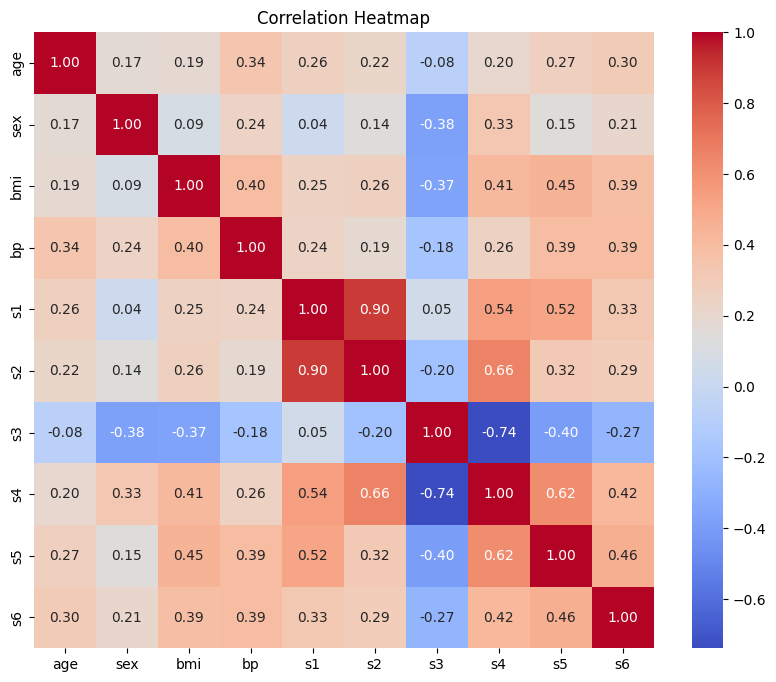

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [12]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


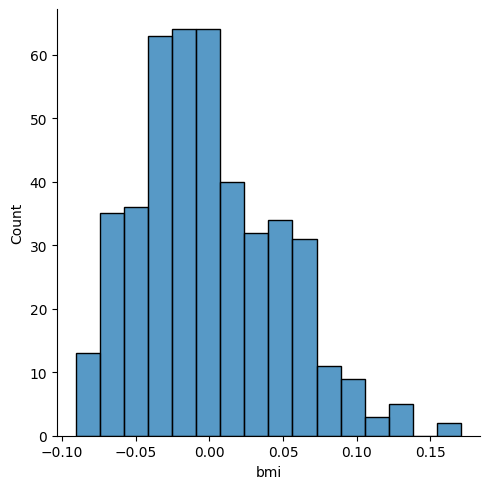

In [14]:
sns.displot(df.bmi)

In [17]:
df.shape

(442, 10)

In [18]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {count}")


age: 0
sex: 0
bmi: 3
bp: 0
s1: 8
s2: 7
s3: 7
s4: 2
s5: 4
s6: 9


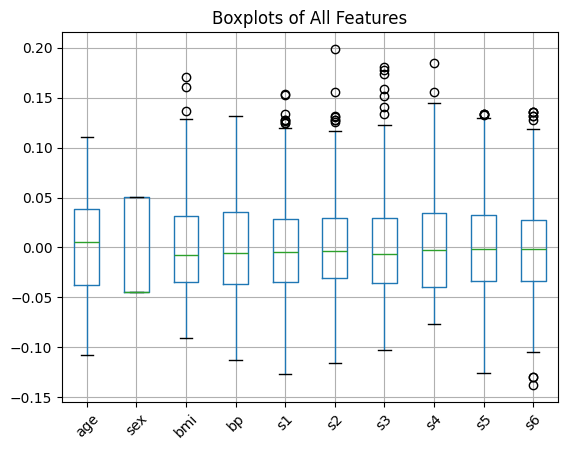

In [19]:
df.boxplot()

plt.title("Boxplots of All Features")
plt.xticks(rotation=45)
plt.show()

In [21]:

X = data.data
y = data.target

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,accuracy_score
import time

knn_brute = KNeighborsRegressor(
    n_neighbors=5,
    algorithm='brute'
)

start = time.time()

knn_brute.fit(X_train, y_train)

train_time_brute = time.time() - start

start = time.time()

y_pred_brute = knn_brute.predict(X_test)

pred_time_brute = time.time() - start

print("R2 Score:", r2_score(y_test, y_pred_brute))

print("Training Time:", train_time_brute)
print("Prediction Time:", pred_time_brute)

R2 Score: 0.43016439526042805
Training Time: 0.001119852066040039
Prediction Time: 0.004636287689208984


In [26]:

knn_kd = KNeighborsRegressor(
    n_neighbors=5,
    algorithm='kd_tree'
)

start = time.time()

knn_kd.fit(X_train, y_train)

train_time_kd = time.time() - start

start = time.time()

y_pred_kd = knn_kd.predict(X_test)

pred_time_kd = time.time() - start

print("R2 Score:", r2_score(y_test, y_pred_kd))
print("Training Time:", train_time_kd)
print("Prediction Time:", pred_time_kd)


R2 Score: 0.43016439526042805
Training Time: 0.0027496814727783203
Prediction Time: 0.0026140213012695312


In [27]:
knn_ball = KNeighborsRegressor(
    n_neighbors=5,
    algorithm='ball_tree'
)

start = time.time()

knn_ball.fit(X_train, y_train)

train_time_ball = time.time() - start

start = time.time()

y_pred_ball = knn_ball.predict(X_test)

pred_time_ball = time.time() - start

print("R2 Score:", r2_score(y_test, y_pred_ball))
print("Training Time:", train_time_ball)
print("Prediction Time:", pred_time_ball)

R2 Score: 0.43016439526042805
Training Time: 0.006286144256591797
Prediction Time: 0.005928993225097656


In [28]:
results = pd.DataFrame({
    "Algorithm": ["Brute Force", "KD Tree", "Ball Tree"],
    "Training Time": [
        train_time_brute,
        train_time_kd,
        train_time_ball
    ],
    "Prediction Time": [
        pred_time_brute,
        pred_time_kd,
        pred_time_ball
    ]
})

print(results)

     Algorithm  Training Time  Prediction Time
0  Brute Force       0.001120         0.004636
1      KD Tree       0.002750         0.002614
2    Ball Tree       0.006286         0.005929


In [29]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28